# 1. Exploración de Datos — Predicting Airline Satisfaction

Primer recorrido por el dataset del episodio, antes de modelar. El objetivo es contestar tres cosas:

- **¿Dónde está la señal?** Qué variables discriminan de verdad y cuáles son ruido.
- **¿Qué forma tiene?** Si las relaciones son monótonas o hay niveles con comportamiento especial
  (por ejemplo, el 0 de las encuestas, que en el dataset original significa "no aplica").
- **¿Hay interacciones?** Efectos que cambian según el nivel de otra variable.

**Métrica oficial de la competencia:** ROC AUC.
**Dataset:** Playground Series S6E10

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (15, 6)
plt.rcParams["figure.dpi"] = 100

SEED = 42

In [2]:
train = pd.read_csv("../data/train.csv")
test  = pd.read_csv("../data/test.csv")

TARGET = "satisfaction"

numericas = ["Age", "Flight Distance", "Departure Delay in Minutes", "Arrival Delay in Minutes"]
encuesta = ["Inflight wifi service", "Departure/Arrival time convenient", "Ease of Online booking",
            "Gate location", "Food and drink", "Online boarding", "Seat comfort",
            "Inflight entertainment", "On-board service", "Leg room service", "Baggage handling",
            "Checkin service", "Cleanliness"]
categoricas = ["Gender", "Customer Type", "Type of Travel", "Class"]

# Version binaria del target para promedios y AUC
train["y"] = train[TARGET].astype(int)

print(f"Train: {train.shape[0]:,} filas x {train.shape[1] - 1} columnas")
print(f"Test:  {test.shape[0]:,} filas x {test.shape[1]} columnas")
print(f"Numericas: {len(numericas)} | Encuesta (0-5): {len(encuesta)} | Categoricas: {len(categoricas)}")

Train: 699,635 filas x 23 columnas
Test:  299,844 filas x 22 columnas
Numericas: 4 | Encuesta (0-5): 13 | Categoricas: 4


## 2. Visión General del Dataset

In [3]:
train.head()

,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,...,Checkin service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Gender,Customer Type,Type of Travel,Class,satisfaction,y
0,0,36,694,4,4,4,3,1,4,1,...,3,1,0,0.0,Female,Loyal Customer,Personal Travel,Eco,False,0
1,1,56,651,5,5,5,5,5,4,4,...,4,3,0,0.0,Male,Loyal Customer,Business travel,Business,True,1
2,2,31,1371,3,4,2,5,3,3,3,...,5,3,0,0.0,Female,Loyal Customer,Personal Travel,Eco,False,0
3,3,10,1616,3,5,3,3,3,3,3,...,4,3,0,0.0,Male,Loyal Customer,Personal Travel,Eco,False,0
4,4,23,481,3,4,3,4,5,3,5,...,3,5,5,0.0,Female,disloyal Customer,Business travel,Eco,False,0


In [4]:
train.drop(columns='y').info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699635 entries, 0 to 699634
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   id                                 699635 non-null  int64  
 1   Age                                699635 non-null  int64  
 2   Flight Distance                    699635 non-null  int64  
 3   Inflight wifi service              699635 non-null  int64  
 4   Departure/Arrival time convenient  699635 non-null  int64  
 5   Ease of Online booking             699635 non-null  int64  
 6   Gate location                      699635 non-null  int64  
 7   Food and drink                     699635 non-null  int64  
 8   Online boarding                    699635 non-null  int64  
 9   Seat comfort                       699635 non-null  int64  
 10  Inflight entertainment             699635 non-null  int64  
 11  On-board service                   6996

In [5]:
train[numericas + encuesta].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,699635.0,39.001928,13.800943,7.0,27.0,40.0,50.0,85.0
Flight Distance,699635.0,1353.778702,954.422566,67.0,631.0,954.0,1814.0,4983.0
Departure Delay in Minutes,699635.0,1.176209,5.982187,0.0,0.0,0.0,0.0,489.0
Arrival Delay in Minutes,699343.0,1.134280,5.749304,0.0,0.0,0.0,0.0,491.0
Inflight wifi service,699635.0,2.778722,1.280419,0.0,2.0,3.0,4.0,5.0
Departure/Arrival time convenient,699635.0,3.156210,1.475390,0.0,2.0,3.0,4.0,5.0
Ease of Online booking,699635.0,2.813240,1.329550,0.0,2.0,3.0,4.0,5.0
Gate location,699635.0,3.013734,1.254014,0.0,2.0,3.0,4.0,5.0
Food and drink,699635.0,3.265644,1.300202,0.0,2.0,3.0,4.0,5.0
Online boarding,699635.0,3.364156,1.288538,0.0,2.0,4.0,4.0,5.0


In [6]:
feats = numericas + encuesta + categoricas

print("Valores nulos por columna (solo las que tienen alguno):")
nulos = pd.DataFrame({"train": train[feats].isna().sum(), "test": test[feats].isna().sum()})
print(nulos[nulos.sum(axis=1) > 0].to_string())
print(f"\nFilas duplicadas (ignorando id y target): {train.duplicated(subset=feats).sum():,}")
print(f"ids unicos en train: {train['id'].is_unique} | en test: {test['id'].is_unique}")

faltan = train["Arrival Delay in Minutes"].isna()
print(f"\nTasa de satisfaccion con Arrival Delay nulo: {train.loc[faltan, 'y'].mean():.4f} "
      f"(n = {faltan.sum()}) vs {train.loc[~faltan, 'y'].mean():.4f} el resto")

Valores nulos por columna (solo las que tienen alguno):


                          train  test
Arrival Delay in Minutes    292   130



Filas duplicadas (ignorando id y target): 0
ids unicos en train: True | en test: True

Tasa de satisfaccion con Arrival Delay nulo: 0.3630 (n = 292) vs 0.4436 el resto


Un solo hueco: 292 nulos en `Arrival Delay in Minutes` (0,04 %), con una demora de salida que tiene correlación de 0,84 con la de llegada para reconstruirlos. Sin duplicados.

## 3. Distribución del Target

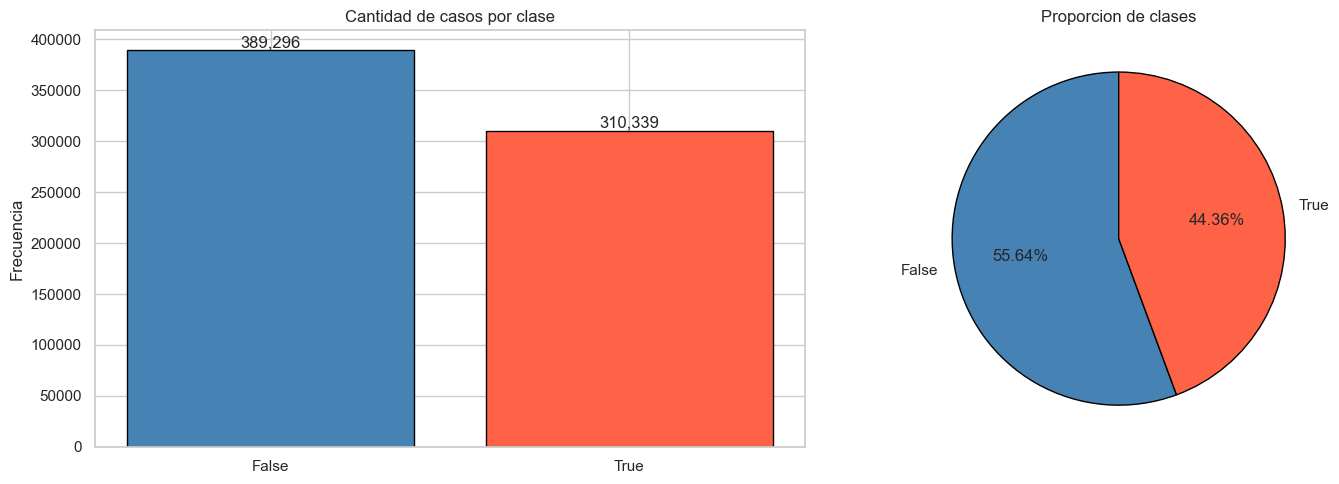

Tasa base (satisfaction = True): 44.3573%


In [7]:
counts = train[TARGET].value_counts()
tasa_base = train["y"].mean()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].bar(counts.index.astype(str), counts.values, color=["steelblue", "tomato"], edgecolor="black")
axes[0].set_title("Cantidad de casos por clase")
axes[0].set_ylabel("Frecuencia")
for i, v in enumerate(counts.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom")

axes[1].pie(counts.values, labels=counts.index.astype(str), autopct="%1.2f%%",
            colors=["steelblue", "tomato"], startangle=90,
            wedgeprops={"edgecolor": "black"})
axes[1].set_title("Proporcion de clases")
plt.tight_layout()
plt.show()

print(f"Tasa base (satisfaction = True): {tasa_base:.4%}")

Clases casi balanceadas (44,36 % satisfechos). Con ROC AUC no hace falta rebalancear.

## 4. Variables Numéricas — Distribuciones

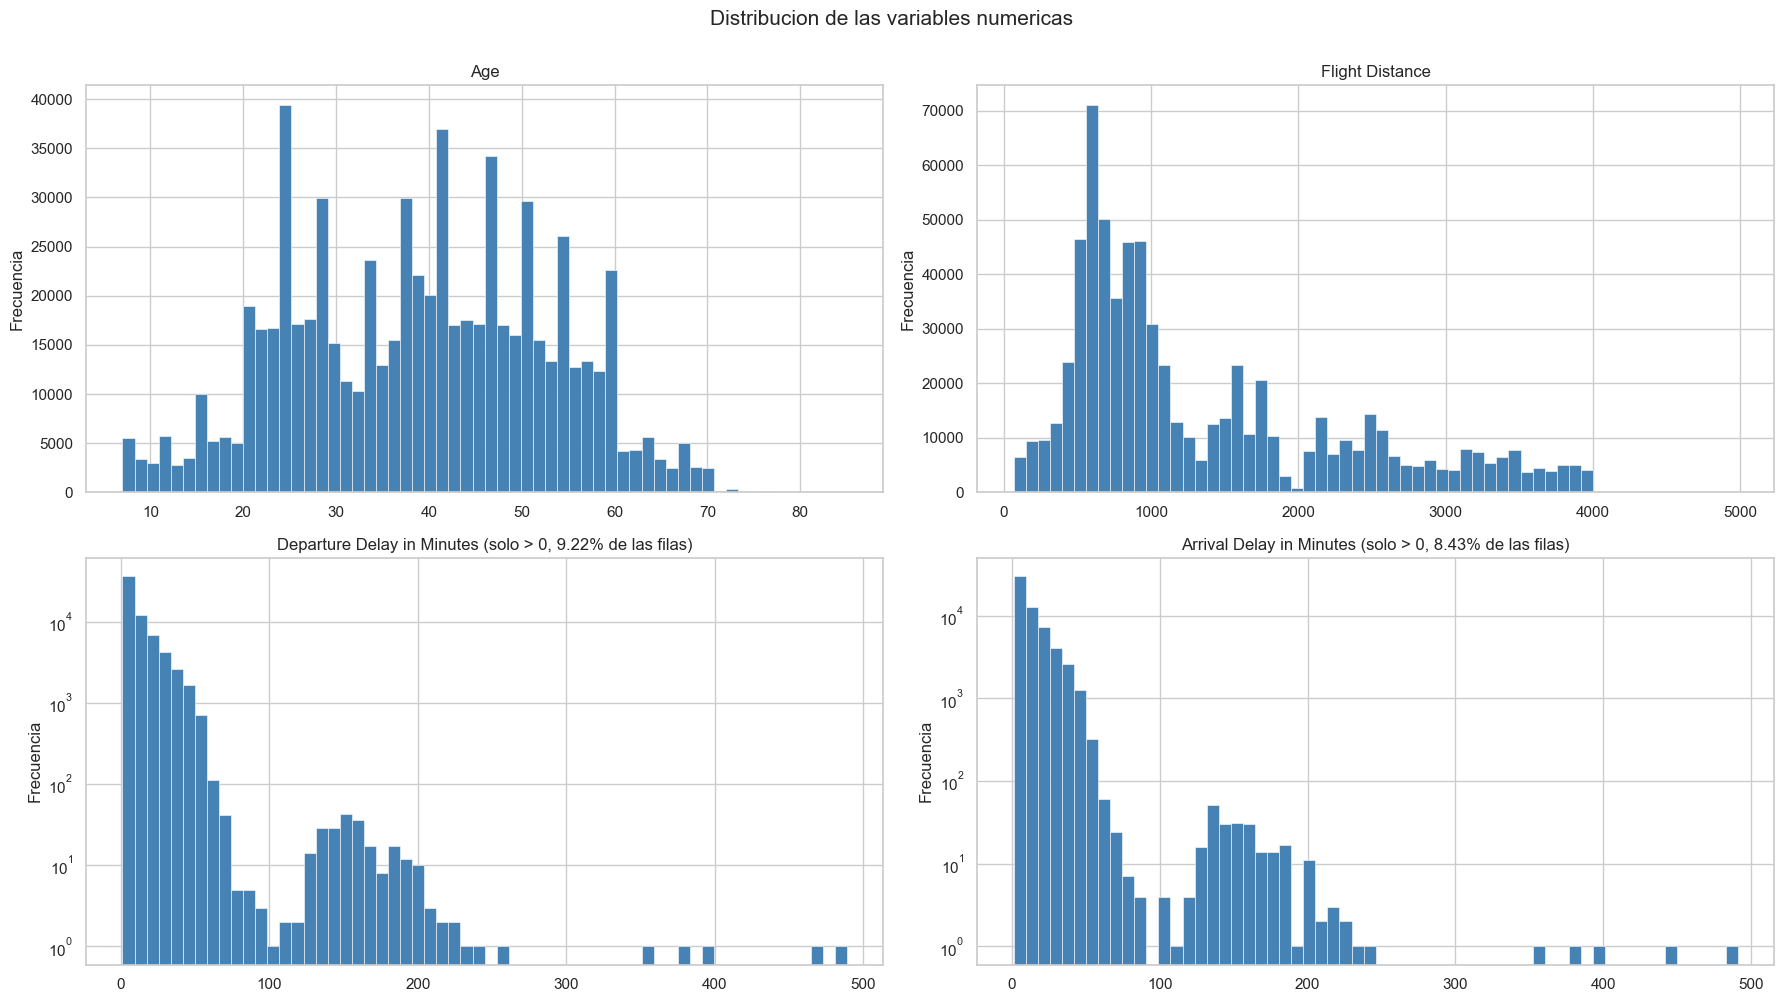

Departure Delay in Minutes   ceros = 90.78%   p99 = 30   max = 489
Arrival Delay in Minutes     ceros = 91.57%   p99 = 28   max = 491

Correlacion entre demoras de salida y llegada: 0.8420


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
for ax, col in zip(axes.ravel(), numericas):
    if "Delay" in col:
        # Casi todo es 0: se grafican solo los vuelos demorados, en escala log
        x = train[col].dropna()
        ax.hist(x[x > 0], bins=60, color="steelblue", edgecolor="white", linewidth=0.4, log=True)
        ax.set_title(f"{col} (solo > 0, {(x > 0).mean():.2%} de las filas)")
    else:
        ax.hist(train[col], bins=60, color="steelblue", edgecolor="white", linewidth=0.4)
        ax.set_title(col)
    ax.set_ylabel("Frecuencia")
plt.suptitle("Distribucion de las variables numericas", fontsize=15, y=1.00)
plt.tight_layout()
plt.show()

for col in numericas[2:]:
    x = train[col].dropna()
    print(f"{col:28s} ceros = {(x == 0).mean():.2%}   p99 = {x.quantile(.99):.0f}   max = {x.max():.0f}")
print(f"\nCorrelacion entre demoras de salida y llegada: "
      f"{train[numericas[2]].corr(train[numericas[3]]):.4f}")

Las demoras son casi siempre 0 (más del 90 % de las filas), con una cola larga que llega a ~490 minutos. `Flight Distance` tiene asimetría a la derecha.

## 5. Variables Numéricas vs Target

Tasa de satisfacción por decil (o por tramo, en las demoras): muestra a la vez la fuerza del efecto y
su forma.

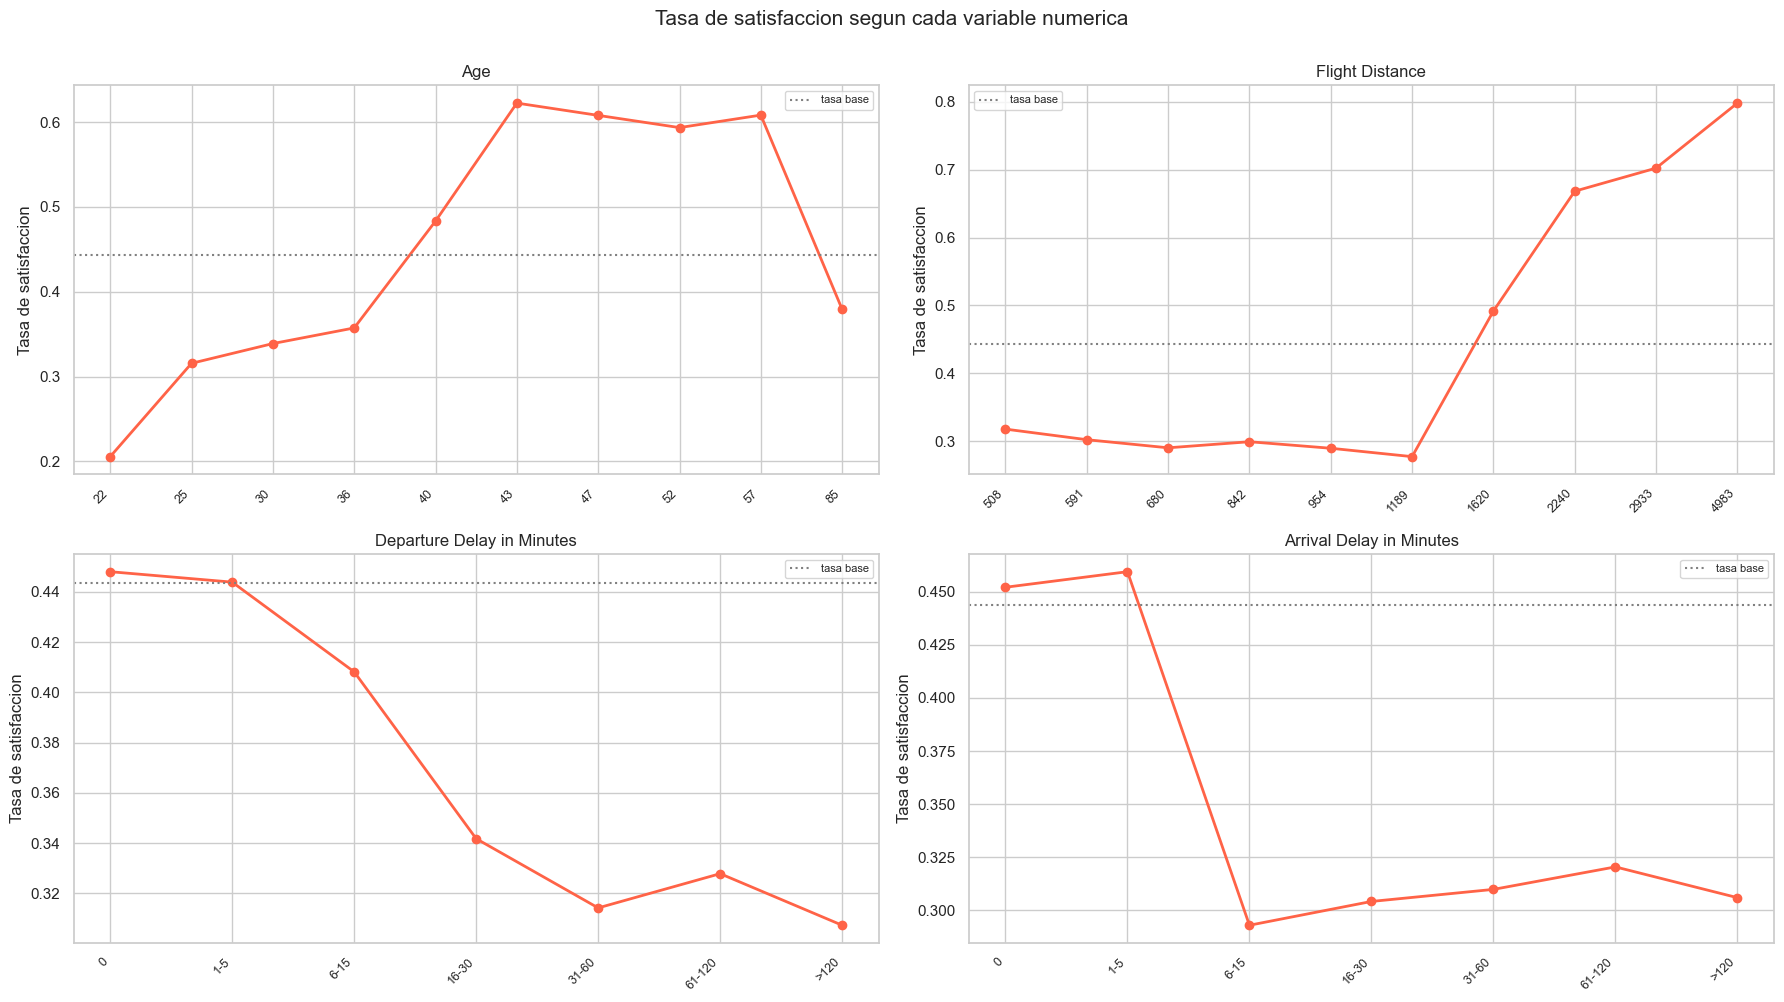

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
for ax, col in zip(axes.ravel(), numericas):
    if "Delay" in col:
        tramos = pd.cut(train[col], [-1, 0, 5, 15, 30, 60, 120, 1000],
                        labels=["0", "1-5", "6-15", "16-30", "31-60", "61-120", ">120"])
        g = train.groupby(tramos, observed=True)["y"].mean()
        etiquetas = list(g.index.astype(str))
    else:
        bins = pd.qcut(train[col], 10, duplicates="drop")
        g = train.groupby(bins, observed=True)["y"].mean()
        etiquetas = [f"{iv.right:.0f}" for iv in g.index]
    ax.plot(range(len(g)), g.values, marker="o", color="tomato", lw=2)
    ax.axhline(tasa_base, color="gray", ls=":", lw=1.5, label="tasa base")
    ax.set_xticks(range(len(g)))
    ax.set_xticklabels(etiquetas, rotation=45, ha="right", fontsize=9)
    ax.set_title(col)
    ax.set_ylabel("Tasa de satisfaccion")
    ax.legend(fontsize=8)
plt.suptitle("Tasa de satisfaccion segun cada variable numerica", fontsize=15, y=1.00)
plt.tight_layout()
plt.show()

In [10]:
# Edad fina: el decil esconde la forma si la relacion no es monotona
g = train.groupby(pd.cut(train["Age"], range(0, 90, 5)), observed=True)["y"].agg(["mean", "size"])
print(g.round(4).to_string())

            mean   size
Age                    
(5, 10]   0.0914  11811
(10, 15]  0.1358  16461
(15, 20]  0.2058  30877
(20, 25]  0.3111  82225
(25, 30]  0.3390  79908
(30, 35]  0.3714  58315
(35, 40]  0.4518  87614
(40, 45]  0.6150  88674
(45, 50]  0.5967  81913
(50, 55]  0.6049  69909
(55, 60]  0.5999  61178
(60, 65]  0.1755  17584
(65, 70]  0.0929  12484
(70, 75]  0.1875    512
(75, 80]  0.1310    168
(80, 85]  0.5000      2


`Age` **no es monótona**: la satisfacción sube de 9 % (≤10 años) a ~61 % entre 40 y 60, y se desploma a 9-18 % después de los 60. Un modelo lineal en la edad se pierde esta forma de meseta. `Flight Distance` es plana (~0,29-0,32) hasta ~1.200 millas y después salta a 0,80 en el último decil. Las demoras sólo pesan como umbral: más de 5 minutos baja la tasa de 0,45 a ~0,30, sin que importe cuánto más.

## 6. Encuesta de Servicio (0-5)

Las 13 variables de encuesta son ordinales de 0 a 5. En el dataset original el 0 significa "no
aplica / no respondió", así que se mira aparte: si su tasa no sigue la tendencia de 1 a 5, conviene
tratarlo como categoría y no como el extremo inferior de la escala.

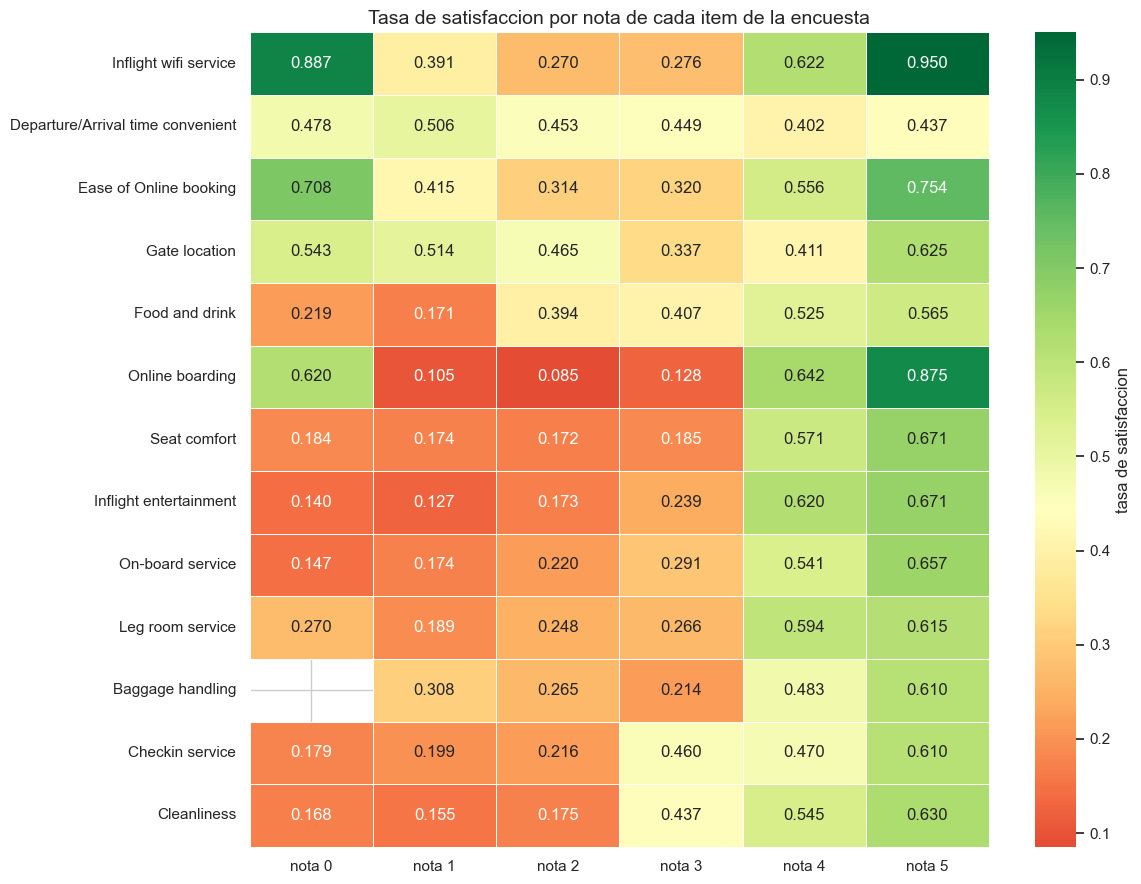

In [11]:
tabla = pd.DataFrame({col: train.groupby(col)["y"].mean() for col in encuesta}).T
tabla.columns = [f"nota {c}" for c in tabla.columns]

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(tabla, annot=True, fmt=".3f", cmap="RdYlGn", center=tasa_base, ax=ax,
            linewidths=0.5, linecolor="white", cbar_kws={"label": "tasa de satisfaccion"})
ax.set_title("Tasa de satisfaccion por nota de cada item de la encuesta", fontsize=14)
plt.tight_layout()
plt.show()

In [12]:
resumen = pd.DataFrame({
    "pct_ceros": [(train[c] == 0).mean() for c in encuesta],
    "tasa_0": [train.loc[train[c] == 0, "y"].mean() for c in encuesta],
    "tasa_1": [train.loc[train[c] == 1, "y"].mean() for c in encuesta],
    "tasa_5": [train.loc[train[c] == 5, "y"].mean() for c in encuesta],
}, index=encuesta)
print(resumen.round(4).to_string())

n_ceros = (train[encuesta] == 0).sum(axis=1)
print("\nCantidad de items en 0 por fila:")
print(train.groupby(n_ceros)["y"].agg(["mean", "size"]).round(4).to_string())

                                   pct_ceros  tasa_0  tasa_1  tasa_5
Inflight wifi service                 0.0187  0.8873  0.3907  0.9504
Departure/Arrival time convenient     0.0368  0.4777  0.5060  0.4373
Ease of Online booking                0.0230  0.7076  0.4146  0.7543
Gate location                         0.0021  0.5430  0.5144  0.6248
Food and drink                        0.0014  0.2189  0.1707  0.5655
Online boarding                       0.0131  0.6204  0.1053  0.8751
Seat comfort                          0.0012  0.1838  0.1736  0.6711
Inflight entertainment                0.0015  0.1402  0.1267  0.6711
On-board service                      0.0011  0.1473  0.1745  0.6566
Leg room service                      0.0024  0.2699  0.1887  0.6151
Baggage handling                      0.0000     NaN  0.3084  0.6096
Checkin service                       0.0013  0.1787  0.1992  0.6103
Cleanliness                           0.0014  0.1683  0.1548  0.6305



Cantidad de items en 0 por fila:
     mean    size
0  0.4424  654914
1  0.3232   29524
2  0.4351    5343
3  0.8625    6914
4  0.9394    2886
5  0.9423      52
6  1.0000       2


El 0 **no** es el extremo inferior de la escala en los ítems digitales: con `Inflight wifi service` = 0 la tasa es 0,89 (contra 0,39 con nota 1), y lo mismo pasa con `Ease of Online booking` (0,71) y `Online boarding` (0,62). Además, las filas con 3 o más ítems en 0 están satisfechas en un 86-94 %. En el resto de los ítems el 0 se comporta como un 1. `Departure/Arrival time convenient` es casi plana (y levemente decreciente).

## 7. Variables Categóricas vs Target

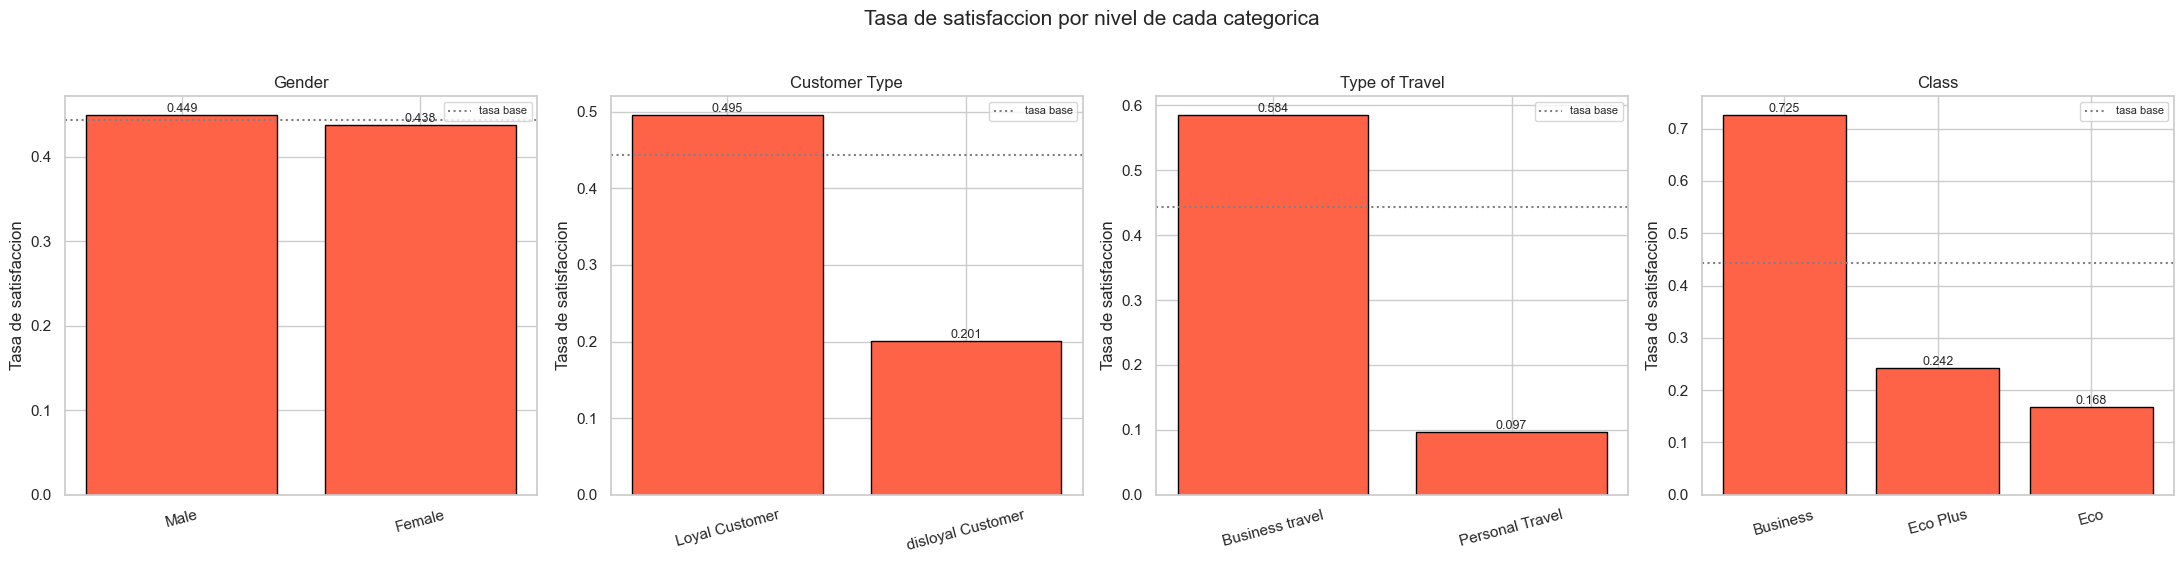

Gender
          mean    size
Gender                
Female  0.4380  347952
Male    0.4491  351683

Customer Type
                     mean    size
Customer Type                    
Loyal Customer     0.4951  576990
disloyal Customer  0.2009  122645



Type of Travel
                   mean    size
Type of Travel                 
Business travel  0.5843  497441
Personal Travel  0.0973  202194

Class
            mean    size
Class                   
Business  0.7253  342212
Eco       0.1676  327404
Eco Plus  0.2422   30019



In [13]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5.5))
for ax, col in zip(axes.ravel(), categoricas):
    g = train.groupby(col)["y"].mean().sort_values(ascending=False)
    ax.bar(g.index.astype(str), g.values, color="tomato", edgecolor="black")
    ax.axhline(tasa_base, color="gray", ls=":", lw=1.5, label="tasa base")
    ax.set_title(col)
    ax.set_ylabel("Tasa de satisfaccion")
    ax.tick_params(axis="x", rotation=15)
    ax.legend(fontsize=8)
    for i, v in enumerate(g.values):
        ax.text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)
plt.suptitle("Tasa de satisfaccion por nivel de cada categorica", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

for col in categoricas:
    g = train.groupby(col)["y"].agg(["mean", "size"])
    print(f"{col}\n{g.round(4).to_string()}\n")

`Type of Travel` y `Class` separan muchísimo: los viajes personales están satisfechos sólo en un 9,7 % y la clase Business en un 72,5 %. `Gender` no se mueve de la tasa base.

## 8. Poder Discriminante — AUC Univariado

El AUC de cada variable usada **sola** como score, comparable con la métrica de la competencia.

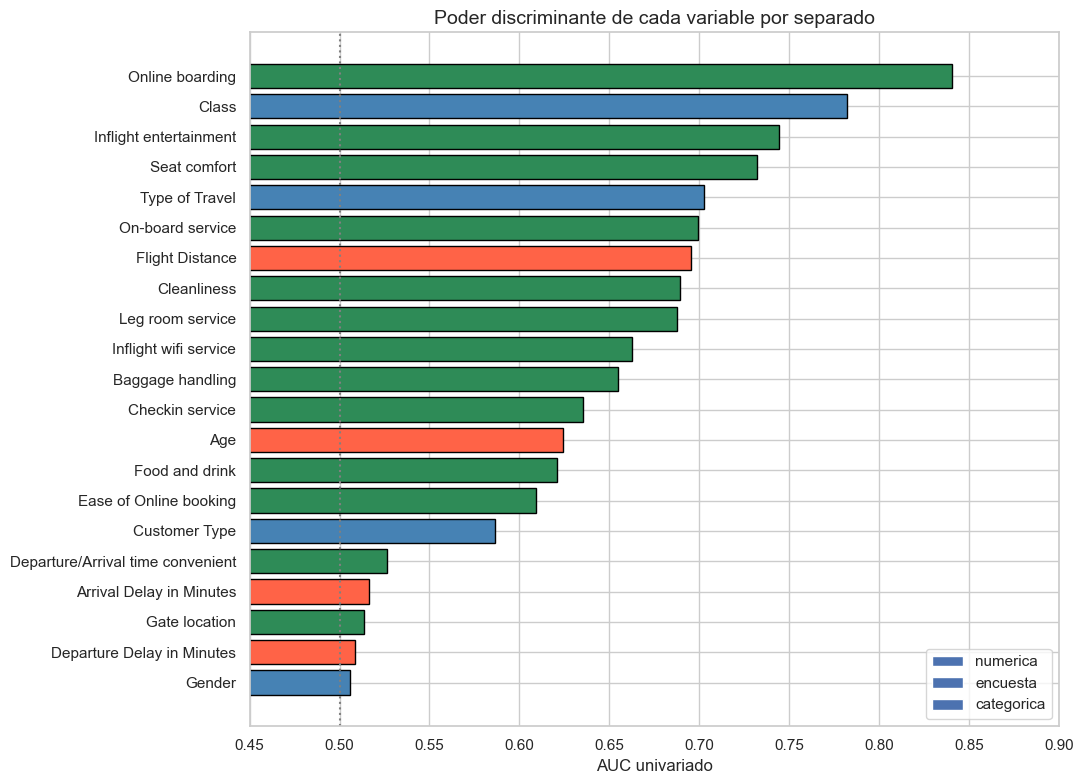

                         variable       tipo    auc signo
                  Online boarding   encuesta 0.8404     +
                            Class categorica 0.7822     +
           Inflight entertainment   encuesta 0.7445     +
                     Seat comfort   encuesta 0.7321     +
                   Type of Travel categorica 0.7027     +
                 On-board service   encuesta 0.6993     +
                  Flight Distance   numerica 0.6956     +
                      Cleanliness   encuesta 0.6894     +
                 Leg room service   encuesta 0.6877     +
            Inflight wifi service   encuesta 0.6627     +
                 Baggage handling   encuesta 0.6549     +
                  Checkin service   encuesta 0.6355     +
                              Age   numerica 0.6244     +
                   Food and drink   encuesta 0.6211     +
           Ease of Online booking   encuesta 0.6090     +
                    Customer Type categorica 0.5862     +
Departure/Arri

In [14]:
filas = []
for col in numericas + encuesta:
    x = train[col].fillna(0)
    auc = roc_auc_score(train["y"], x)
    filas.append({"variable": col, "tipo": "numerica" if col in numericas else "encuesta",
                  "auc": max(auc, 1 - auc), "signo": "+" if auc >= 0.5 else "-"})
for col in categoricas:
    # Se usa la tasa de target por nivel como score (equivale a ordenar por el nivel)
    score = train[col].map(train.groupby(col)["y"].mean())
    filas.append({"variable": col, "tipo": "categorica",
                  "auc": roc_auc_score(train["y"], score), "signo": "+"})

poder = pd.DataFrame(filas).sort_values("auc", ascending=False).reset_index(drop=True)

paleta = {"numerica": "tomato", "encuesta": "seagreen", "categorica": "steelblue"}
fig, ax = plt.subplots(figsize=(11, 8))
ax.barh(poder["variable"][::-1], poder["auc"][::-1],
        color=[paleta[t] for t in poder["tipo"][::-1]], edgecolor="black")
ax.axvline(0.5, color="gray", ls=":", lw=1.5)
for t, c in paleta.items():
    ax.barh([], [], color=c, label=t)
ax.set_xlabel("AUC univariado")
ax.set_title("Poder discriminante de cada variable por separado", fontsize=14)
ax.set_xlim(0.45, 0.9)
ax.legend()
plt.tight_layout()
plt.show()

print(poder.round(4).to_string(index=False))

`Online boarding` es por lejos la mejor variable suelta (0,84). Detrás vienen `Class` (0,78) y los ítems de confort a bordo. Las demoras, `Gate location`, `Departure/Arrival time convenient` y `Gender` están pegadas a 0,50. Como en episodios anteriores, el AUC de las categóricas usa la tasa del target por nivel y sobreestima un poco.

## 9. Interacciones

Se cruzan los pares donde es esperable que el efecto de una variable dependa de la otra: el tipo de
viaje con la clase y la lealtad, y el wifi (un item con fama de comportarse distinto) con el tipo de
viaje.

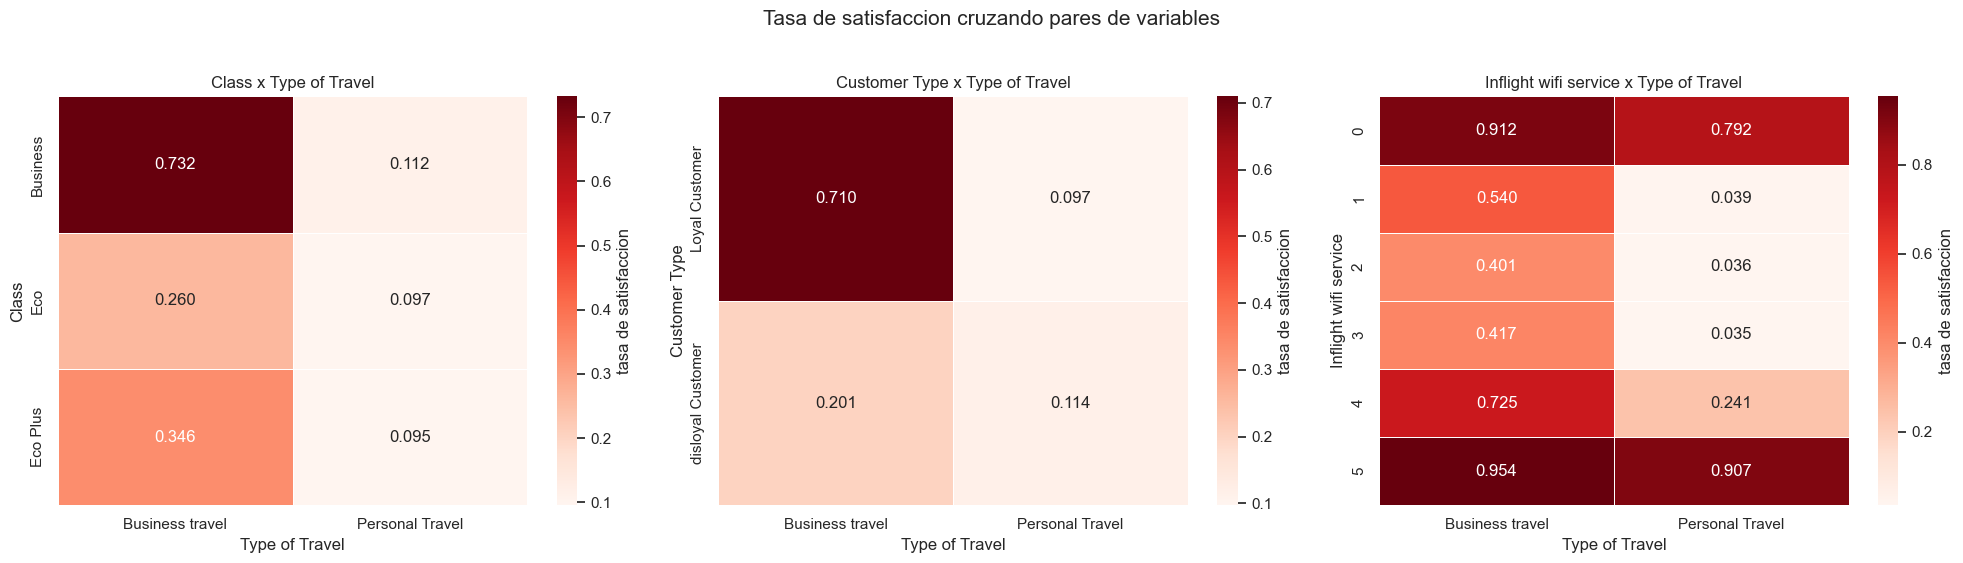

In [15]:
pares = [("Class", "Type of Travel"),
         ("Customer Type", "Type of Travel"),
         ("Inflight wifi service", "Type of Travel")]

fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))
for ax, (a, b) in zip(axes, pares):
    piv = train.pivot_table(index=a, columns=b, values="y", aggfunc="mean")
    sns.heatmap(piv, annot=True, fmt=".3f", cmap="Reds", ax=ax,
                linewidths=0.5, linecolor="white", cbar_kws={"label": "tasa de satisfaccion"})
    ax.set_title(f"{a} x {b}")
plt.suptitle("Tasa de satisfaccion cruzando pares de variables", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

In [16]:
# Si el efecto fuera aditivo en log-odds, la diferencia entre columnas seria constante por fila.
MIN_POS = 20

for a, b in pares:
    tasa = train.pivot_table(index=a, columns=b, values="y", aggfunc="mean")
    pos  = train.pivot_table(index=a, columns=b, values="y", aggfunc="sum")
    neg  = train.pivot_table(index=a, columns=b, values="y", aggfunc=lambda s: (1 - s).sum())
    lo   = np.log(tasa.clip(1e-6, 1 - 1e-6) / (1 - tasa.clip(1e-6, 1 - 1e-6)))
    dif  = (lo.iloc[:, 0] - lo.iloc[:, 1]).round(3)
    solido = ((pos >= MIN_POS) & (neg >= MIN_POS)).all(axis=1)

    print(f"{a} x {b}")
    print(f"  delta log-odds ({tasa.columns[0]} vs {tasa.columns[1]}) por fila: {dif.to_dict()}")
    d = dif[solido]
    rango = d.max() - d.min()
    print(f"  rango del delta sobre las {len(d)} filas solidas: {rango:.3f}"
          f"   -> {'INTERACCION' if rango > 0.6 else 'aproximadamente aditivo'}\n")

Class x Type of Travel
  delta log-odds (Business travel vs Personal Travel) por fila: {'Business': 3.078, 'Eco': 1.184, 'Eco Plus': 1.614}
  rango del delta sobre las 3 filas solidas: 1.894   -> INTERACCION



Customer Type x Type of Travel
  delta log-odds (Business travel vs Personal Travel) por fila: {'Loyal Customer': 3.122, 'disloyal Customer': 0.668}
  rango del delta sobre las 1 filas solidas: 0.000   -> aproximadamente aditivo



Inflight wifi service x Type of Travel
  delta log-odds (Business travel vs Personal Travel) por fila: {0: 0.999, 1: 3.359, 2: 2.896, 3: 2.975, 4: 2.115, 5: 0.751}
  rango del delta sobre las 6 filas solidas: 2.608   -> INTERACCION



**`Class` × `Type of Travel` es una interacción fuerte**: viajar por trabajo vale +3,08 de log-odds en Business pero sólo +1,18 en Eco. **El wifi también interactúa**: en viajes personales las notas 1-3 dan ~3,5 % de satisfacción y sólo la 5 la rescata (0,91), mientras que en viajes de trabajo la curva es mucho más suave. El cruce de `Customer Type` no se puede juzgar: la combinación desleal + viaje personal tiene sólo 105 filas (los clientes desleales viajan casi siempre por trabajo).

## 10. Correlaciones

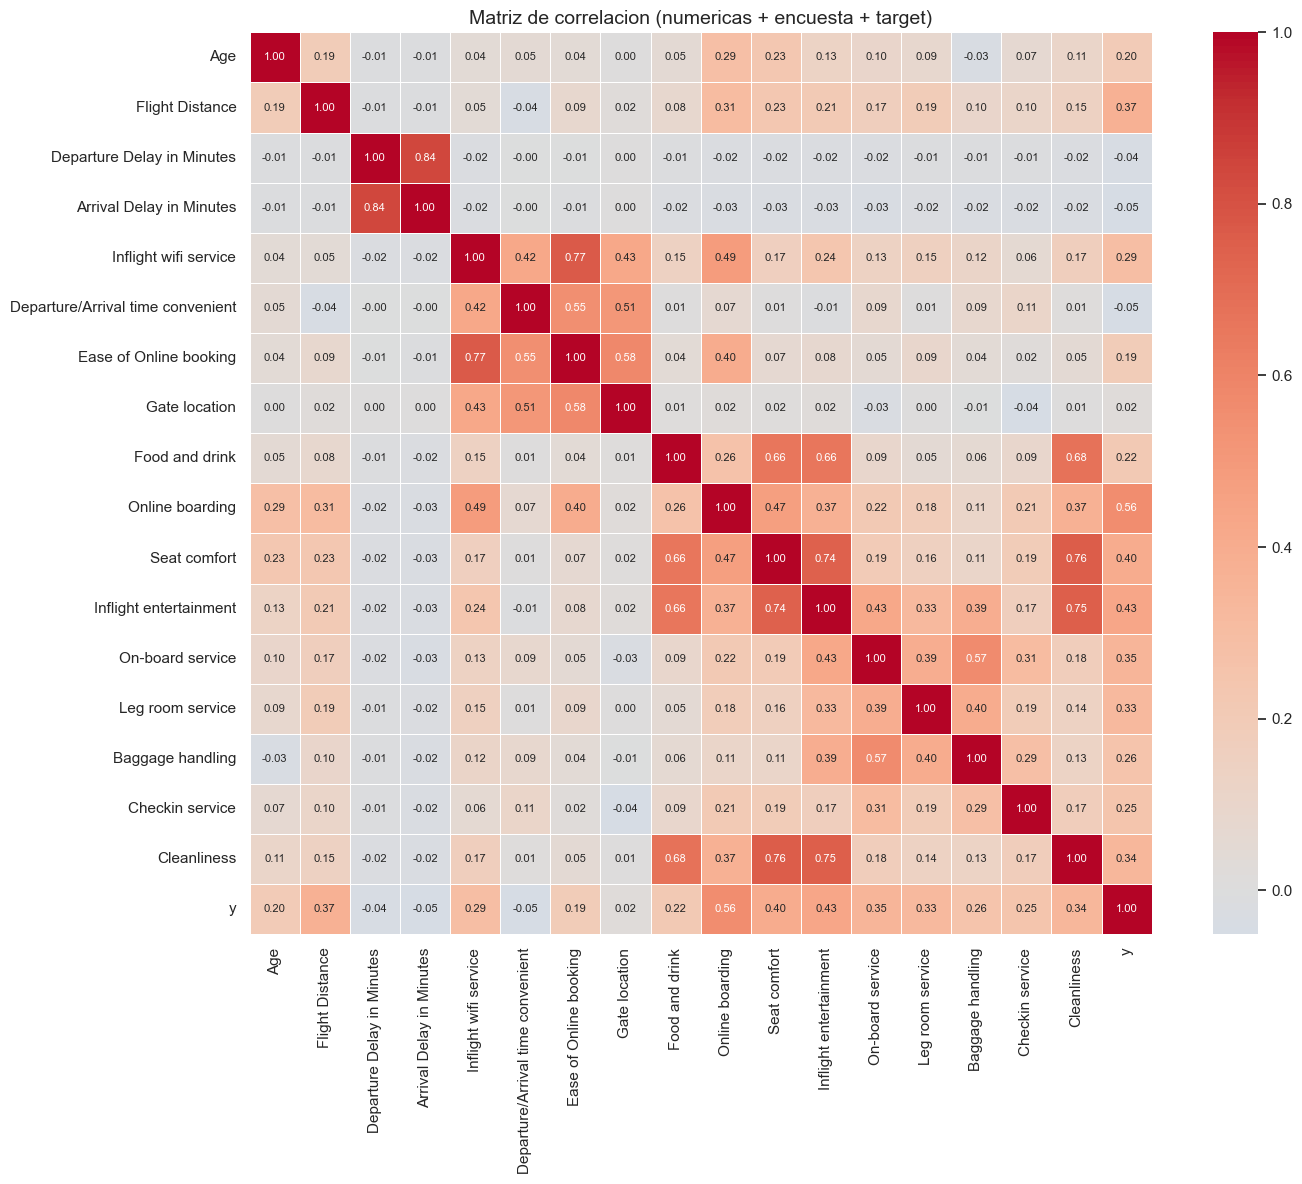

Pares de features mas correlacionados:
Departure Delay in Minutes  Arrival Delay in Minutes    0.8420
Inflight wifi service       Ease of Online booking      0.7720
Seat comfort                Cleanliness                 0.7626
Inflight entertainment      Cleanliness                 0.7510
Seat comfort                Inflight entertainment      0.7448
Food and drink              Cleanliness                 0.6782
                            Inflight entertainment      0.6565
                            Seat comfort                0.6560


In [17]:
cols_corr = numericas + encuesta + ["y"]
corr = train[cols_corr].corr()

fig, ax = plt.subplots(figsize=(15, 12))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax,
            linewidths=0.5, linecolor="white", square=True, annot_kws={"size": 8})
ax.set_title("Matriz de correlacion (numericas + encuesta + target)", fontsize=14)
plt.tight_layout()
plt.show()

pares_corr = (corr.drop(index="y", columns="y").where(np.triu(np.ones(len(corr) - 1, dtype=bool), k=1))
              .stack().sort_values(key=abs, ascending=False))
print("Pares de features mas correlacionados:")
print(pares_corr.head(8).round(4).to_string())

Hay un bloque de ítems de confort a bordo que se mueven juntos (`Seat comfort`, `Cleanliness`, `Inflight entertainment`, `Food and drink`: 0,66-0,76) y otro de ítems digitales (`Inflight wifi service` con `Ease of Online booking`: 0,77). Las dos demoras son casi la misma variable (0,84).

## 11. Train vs Test

Comparación rápida de distribuciones para descartar drift entre los dos conjuntos.

In [18]:
filas = []
for col in numericas + encuesta:
    filas.append({"variable": col, "media_train": train[col].mean(), "media_test": test[col].mean(),
                  "dif_en_std": (test[col].mean() - train[col].mean()) / train[col].std()})
for col in categoricas:
    p_tr = train[col].value_counts(normalize=True)
    p_te = test[col].value_counts(normalize=True)
    filas.append({"variable": col, "media_train": np.nan, "media_test": np.nan,
                  "dif_en_std": (p_te - p_tr).abs().max()})
drift = pd.DataFrame(filas)
print(drift.round(4).to_string(index=False))
print(f"\nMaxima diferencia absoluta: {drift['dif_en_std'].abs().max():.4f}")

                         variable  media_train  media_test  dif_en_std
                              Age      39.0019     38.9930     -0.0006
                  Flight Distance    1353.7787   1353.3689     -0.0004
       Departure Delay in Minutes       1.1762      1.1566     -0.0033
         Arrival Delay in Minutes       1.1343      1.1202     -0.0025
            Inflight wifi service       2.7787      2.7766     -0.0017
Departure/Arrival time convenient       3.1562      3.1516     -0.0031
           Ease of Online booking       2.8132      2.8126     -0.0005
                    Gate location       3.0137      3.0131     -0.0005
                   Food and drink       3.2656      3.2700      0.0034
                  Online boarding       3.3642      3.3657      0.0012
                     Seat comfort       3.5689      3.5721      0.0025
           Inflight entertainment       3.4539      3.4560      0.0016
                 On-board service       3.5174      3.5133     -0.0033
      

Sin drift: la mayor diferencia de medias entre train y test es 0,004 desvíos, y las proporciones de las categóricas coinciden con una diferencia de 0,2 % como máximo.

## 12. Conclusiones

- **Dataset limpio y grande**: 699.635 × 22, sin duplicados. El único hueco son 292 nulos en `Arrival Delay in Minutes` (0,04 %).
- **Clases casi balanceadas**: 44,36 % de satisfechos.
- **La señal más fuerte es `Online boarding`** (AUC 0,84, la tasa va de 0,11 con nota 1 a 0,88 con nota 5). Detrás vienen `Class` (0,78), `Inflight entertainment` (0,74), `Seat comfort` (0,73) y `Type of Travel` (0,70).
- **El 0 de la encuesta es una categoría aparte en los ítems digitales**: con wifi = 0 la tasa es 0,89, contra 0,39 con nota 1. Pasa lo mismo en `Ease of Online booking` y `Online boarding`, y las filas con 3 o más ítems en 0 están satisfechas en un 86-94 %.
- **Hay relaciones no monótonas**: `Age` forma una meseta de ~0,60 entre 40 y 60 años, con caídas a ambos lados (9 % abajo de 10 y después de 65). `Flight Distance` sólo empieza a importar por encima de ~1.200 millas.
- **Las demoras casi no aportan**: más del 90 % son 0, el AUC ronda 0,51 y su único efecto es un umbral (más de 5 min baja la tasa de 0,45 a ~0,30).
- **Ruido**: `Gender` (0,51), `Gate location` (0,51) y `Departure/Arrival time convenient` (0,53).
- **Hay interacciones fuertes con el tipo de viaje**: el efecto de viajar por trabajo vale +3,08 de log-odds en Business y +1,18 en Eco, y las notas medias de wifi hunden la satisfacción en viajes personales (~3,5 %) mucho más que en viajes de trabajo (~40 %).
- **Hay colinealidad entre ítems de la encuesta** (confort a bordo 0,66-0,76; wifi con reserva online 0,77) y entre las dos demoras (0,84).
- **Train y test tienen la misma distribución** (diferencias de 0,004 desvíos como máximo).